## Detecting outliers and adapting models to these

In [1]:
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

from pinard import utils
from pinard import preprocessing as pp
from pinard.model_selection import train_test_split_idx

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler


# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
simplefilter(action='ignore', category=UserWarning)

### Importation of the datasets

In [2]:
# Function to load a CSV file with automatic separator detection

def load_csv_auto_sep(mode, data_source, type_data, verbose=True):
 
    # Regression: 'BeerOriginalExtract' or 'Digest_0.8' or 'YamProtein' //
    # Classification: 'CoffeeSpecies' or 'Malaria2024' or 'mDigest_custom3' or 'WhiskyConcentration' or 'YamMould'

    ## Importation of the datasets with the adapted path
    file_name = Path("Data/%s/%s"% (mode,data_source))
    full_path = str(file_name.resolve()).replace("\\", "/")
    path = full_path + "/%s.csv" % type_data

    with open(path, 'r', newline='', encoding='utf-8') as f:
        # Read a small portion of the file to detect the separator
        excerpt = f.read(1024)
        f.seek(0)  # return to the beginning of the file

        # Detection of the dialect
        dialect = csv.Sniffer().sniff(excerpt)
        sep = dialect.delimiter

        if verbose: print("Detected separator : %s" % sep)
        
        # Load the file with pandas
        df = pd.read_csv(f, delimiter=sep)

        if type_data[0]=='Y' and len(df.columns) > 1:
            # Drop the useless column if it exists
            df = df.drop(columns=[df.columns[1]])
        
        return df

In [29]:
mode = 'Classification'
data_source = 'YamMould'

Xcal = load_csv_auto_sep(mode=mode, data_source=data_source, type_data='Xcal')
Xval = load_csv_auto_sep(mode=mode, data_source=data_source, type_data='Xval')
Ycal = load_csv_auto_sep(mode=mode, data_source=data_source, type_data='Ycal')
Yval = load_csv_auto_sep(mode=mode, data_source=data_source, type_data='Yval')

print("Number of spectra for calibration: ", len(Ycal))
print("Number of spectra for test: ", len(Yval))
display(Xcal.head(5))

Detected separator : ;
Detected separator : ;
Detected separator : 
Detected separator : 
Number of spectra for calibration:  359
Number of spectra for test:  222


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V1041,V1042,V1043,V1044,V1045,V1046,V1047,V1048,V1049,V1050
0,0.104173,0.106633,0.108911,0.111115,0.112967,0.114301,0.115263,0.116030,0.116603,0.116832,...,0.705995,0.707871,0.709486,0.710800,0.711762,0.712256,0.712456,0.712440,0.712097,0.711682
1,0.104999,0.107303,0.109628,0.111981,0.113842,0.115009,0.115808,0.116570,0.117305,0.117779,...,0.705372,0.707229,0.708835,0.710022,0.710786,0.711361,0.711579,0.711587,0.711348,0.710855
2,0.103015,0.105791,0.108403,0.110632,0.112395,0.113866,0.115003,0.115697,0.116193,0.116573,...,0.704418,0.706320,0.707886,0.709076,0.709901,0.710420,0.710665,0.710634,0.710325,0.709872
3,0.108191,0.110671,0.113100,0.115619,0.117804,0.119361,0.120362,0.120992,0.121503,0.121823,...,0.625951,0.627607,0.628954,0.630020,0.630755,0.631282,0.631540,0.631585,0.631383,0.630960
4,0.116045,0.119038,0.121745,0.124131,0.126005,0.127366,0.128375,0.129159,0.129739,0.130012,...,0.624218,0.625825,0.627094,0.628123,0.628934,0.629413,0.629632,0.629611,0.629445,0.629116


### Construction of the pipelines

In [30]:
rd_seed = 42
rd_seed = np.random.seed(rd_seed)

x, y = pd.concat([Xcal,Xval], axis=0).values, pd.concat([Ycal,Yval], axis=0).values

### Declare preprocessing methods that will be used
preprocessing = [   ('id', pp.IdentityTransformer()),
                    ('baseline', pp.Baseline()),
                    ('derivate', pp.Derivate()),
                    ('detrend', pp.Detrend()),
                    ('MSC', pp.MultiplicativeScatterCorrection()),
                    ('normalize', pp.Normalize()),
                    ('RNV', pp.RobustNormalVariate()),
                    ('savgol', pp.SavitzkyGolay()),
                    ('simplescale', pp.SimpleScale()),
                    ('SNV', pp.StandardNormalVariate()),
                    ('haar', pp.Wavelet('haar')),
                    ('gaussian', pp.Gaussian(order = 2, sigma = 1)),
                    ('PCA', PCA())
                ]

# Apply the preprocessing methods to the calibration dataset
transformed_datasets = {}
for name, method in preprocessing:
    x = method.fit_transform(Xcal)
    transformed_datasets[name] = x

### Detection of outliers with PCA

In [31]:
scaler = StandardScaler(with_std=False)
dict_outliers = {}
for name, method in preprocessing:
    x = transformed_datasets[name]
    X_scaled = scaler.fit_transform(x)

    # Perform PCA on the scaled data
    X_pca = PCA(n_components=1).fit_transform(X_scaled)

    # Store the PCA scores in a DataFrame for easier manipulation
    scores_df = pd.DataFrame(X_pca, columns=['PC1'])

    # Compute the bounds for extreme individuals
    mean_PC1 = scores_df['PC1'].mean()
    std_PC1 = scores_df['PC1'].std()
    lower_bound = mean_PC1 - 2 * std_PC1
    upper_bound = mean_PC1 + 2 * std_PC1

    # Filter the extreme individuals based on the bounds
    outliers = scores_df[
        (scores_df['PC1'] < lower_bound) | (scores_df['PC1'] > upper_bound)
    ]
    
    # Store the extreme individuals in the dictionary
    dict_outliers[name] = outliers.index.tolist()

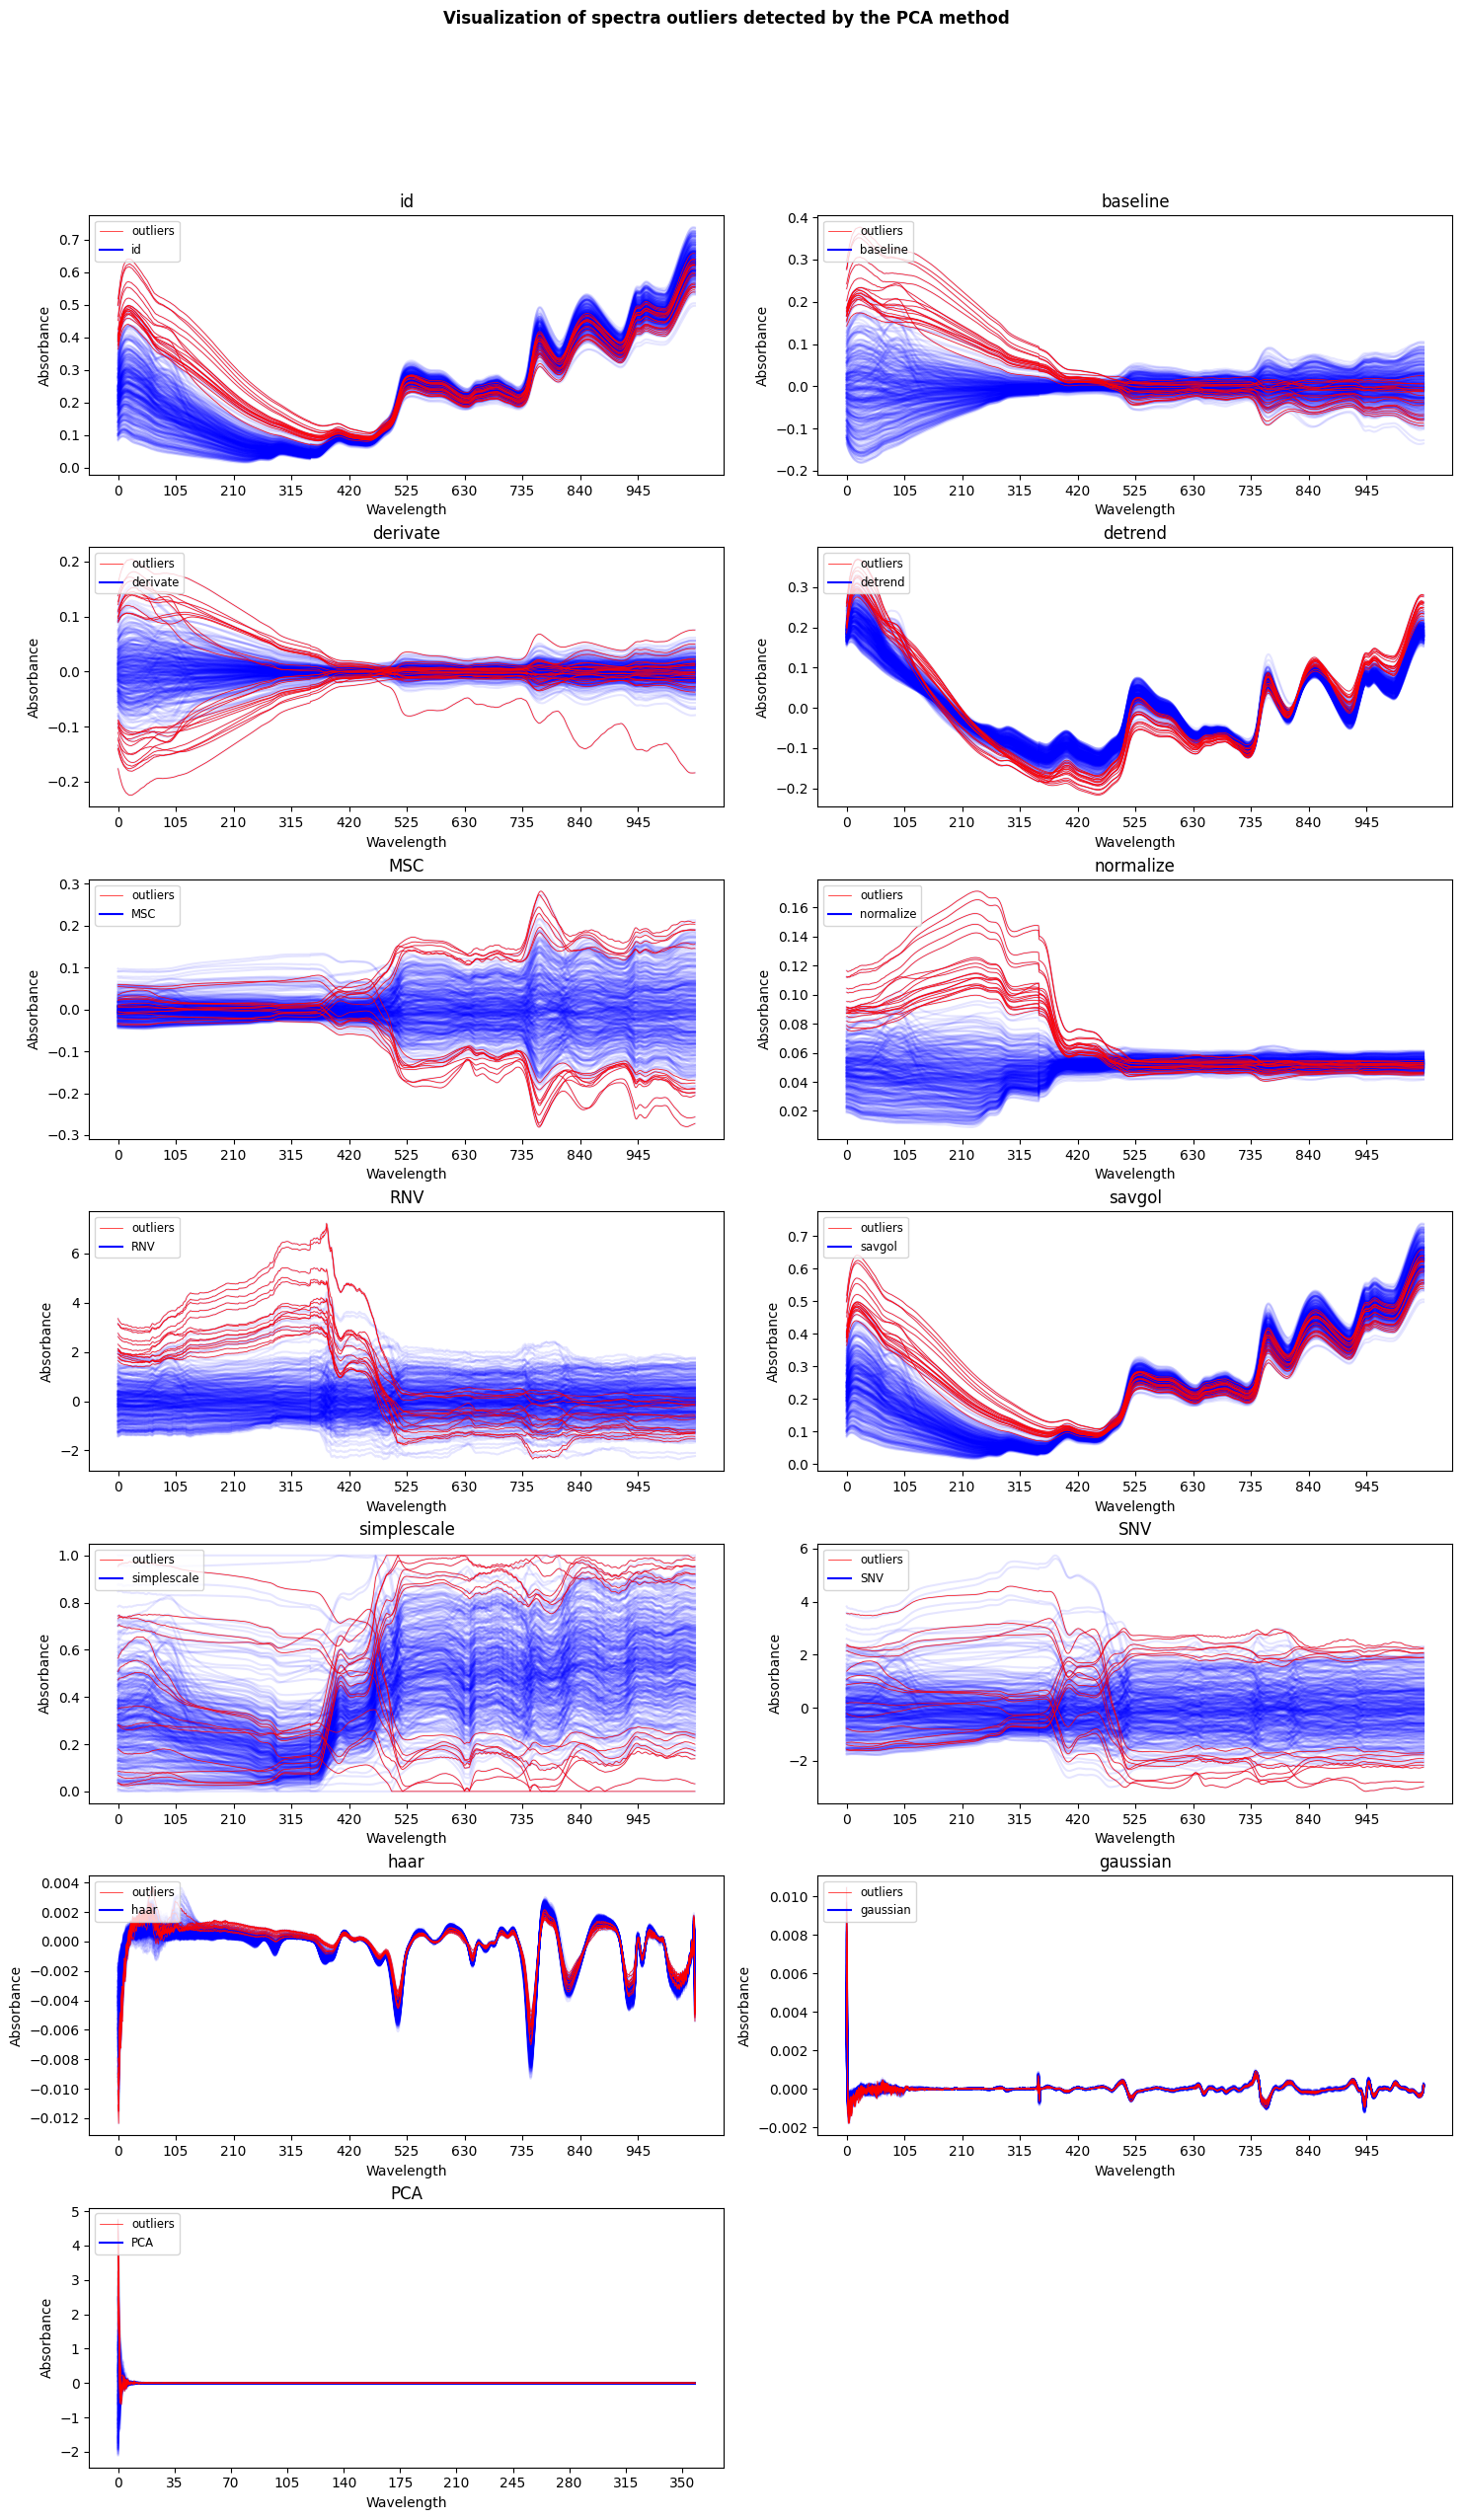

In [32]:
def plot_spectra_outliers(X, dict_outliers, names, title='Visualization of the spectra with outliers', save_fig=False):
    if isinstance(X, pd.DataFrame):
        X = [X.values]
    elif isinstance(X, np.ndarray):
            X = [X]

    fig, axs = plt.subplots((len(X)+1)//2, 2, figsize=(15, 4*len(X)//2), dpi=100)
    axs = axs.flatten()
    for i, ax in enumerate(axs):
        if i >= len(X):
            ax.axis('off')
        else:
            name = names[i]
            dataset = X[i]
            if isinstance(dataset, pd.DataFrame):
                 dataset = dataset.values
            outliers = dict_outliers[name]
            ax.set_title(name)
            ax.set_xlabel('Wavelength')
            ax.set_ylabel('Absorbance')
            ax.set_xticks(np.arange(0, dataset.shape[1], dataset.shape[1]//10))
            ax.plot(dataset.T, color='blue', alpha = 0.1)
            
            if len(outliers) > 0:
                ax.plot(dataset[outliers,:].T, color='red', linewidth=0.5)
                ax.plot([], [], color='red', label='outliers', linewidth=0.5)
            
            ax.plot([], [], color='blue', label=name)
            ax.legend(loc='upper left', fontsize='small')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.suptitle(title, fontweight='bold')
    
    # Save figure if required in the folder Figures/outliers_detection
    if save_fig: 
        fig.savefig("Figures/outliers_detection/PCA/%s_comp_dissimilarity.png" % data_source, dpi=300)
    plt.show()


# Plot the spectra
plot_spectra_outliers(list(transformed_datasets.values()),
                      dict_outliers = dict_outliers,
                      names = list(transformed_datasets.keys()),
                      title = 'Visualization of spectra outliers detected by the PCA method',
                      save_fig = True)

### Detection of outliers with Data Depth Theory

In [33]:
def diff_abs_j(X,j):
    N_T, n_x = X.shape

    # Compute the differences of a given absorbance by all other absorbances in the same column of the spectral dataset
    Q = np.tile(X[j,:], (N_T,1))
    X_2 = X - Q

    # Compute the norm 2 of each line of this matrix and then square it
    X_fin = np.square(np.linalg.norm(X_2, axis=0))

    return X_fin

def detect_outliers_DDT_ED(X, kM=2.0):
    if isinstance(X, pd.DataFrame):
        X = X.values

    N_T, n_x = X.shape

    # Compute the ED for all spectrum
    distances = np.array([diff_abs_j(X,j) for j in range(N_T)])
    R = np.linalg.norm(distances, axis=1, ord=1)
    ED = 1/N_T * np.sqrt(R)

    # Define a threshold and detect outliers
    threshold = kM * np.median(ED)
    mask = ED > threshold
    outliers_ind = np.where(mask)
    return list(outliers_ind[0])

def identify_mrs(X):
    if isinstance(X, pd.DataFrame): X = X.values
    N_T, n_x = X.shape
    sdiff = np.zeros(N_T)
    sequal = np.zeros(N_T)

    for j in range(N_T):
        for i in range(n_x):
            l1 = np.sum(X[:, i] > X[j, i])
            l2 = np.sum(X[:, i] == X[j, i])
            l3 = np.sum(X[:, i] < X[j, i])
            sdiff[j] += abs(l1 - l3)
            sequal[j] += l2

    min_sdiff = np.min(sdiff)
    candidates = np.where(sdiff == min_sdiff)[0]
    if len(candidates) > 1:
        max_sequal = sequal[candidates].max()
        mrs_index = candidates[sequal[candidates] == max_sequal][0]
    else:
        mrs_index = candidates[0]
    return mrs_index

In [34]:
dict_outliers = {}
for name, method in preprocessing:
    x = transformed_datasets[name]

    # Perform outliers detection with the DDT method
    outliers_ind = detect_outliers_DDT_ED(x, kM=2.0)
    
    # Store the extreme individuals in the dictionary
    dict_outliers[name] = outliers_ind

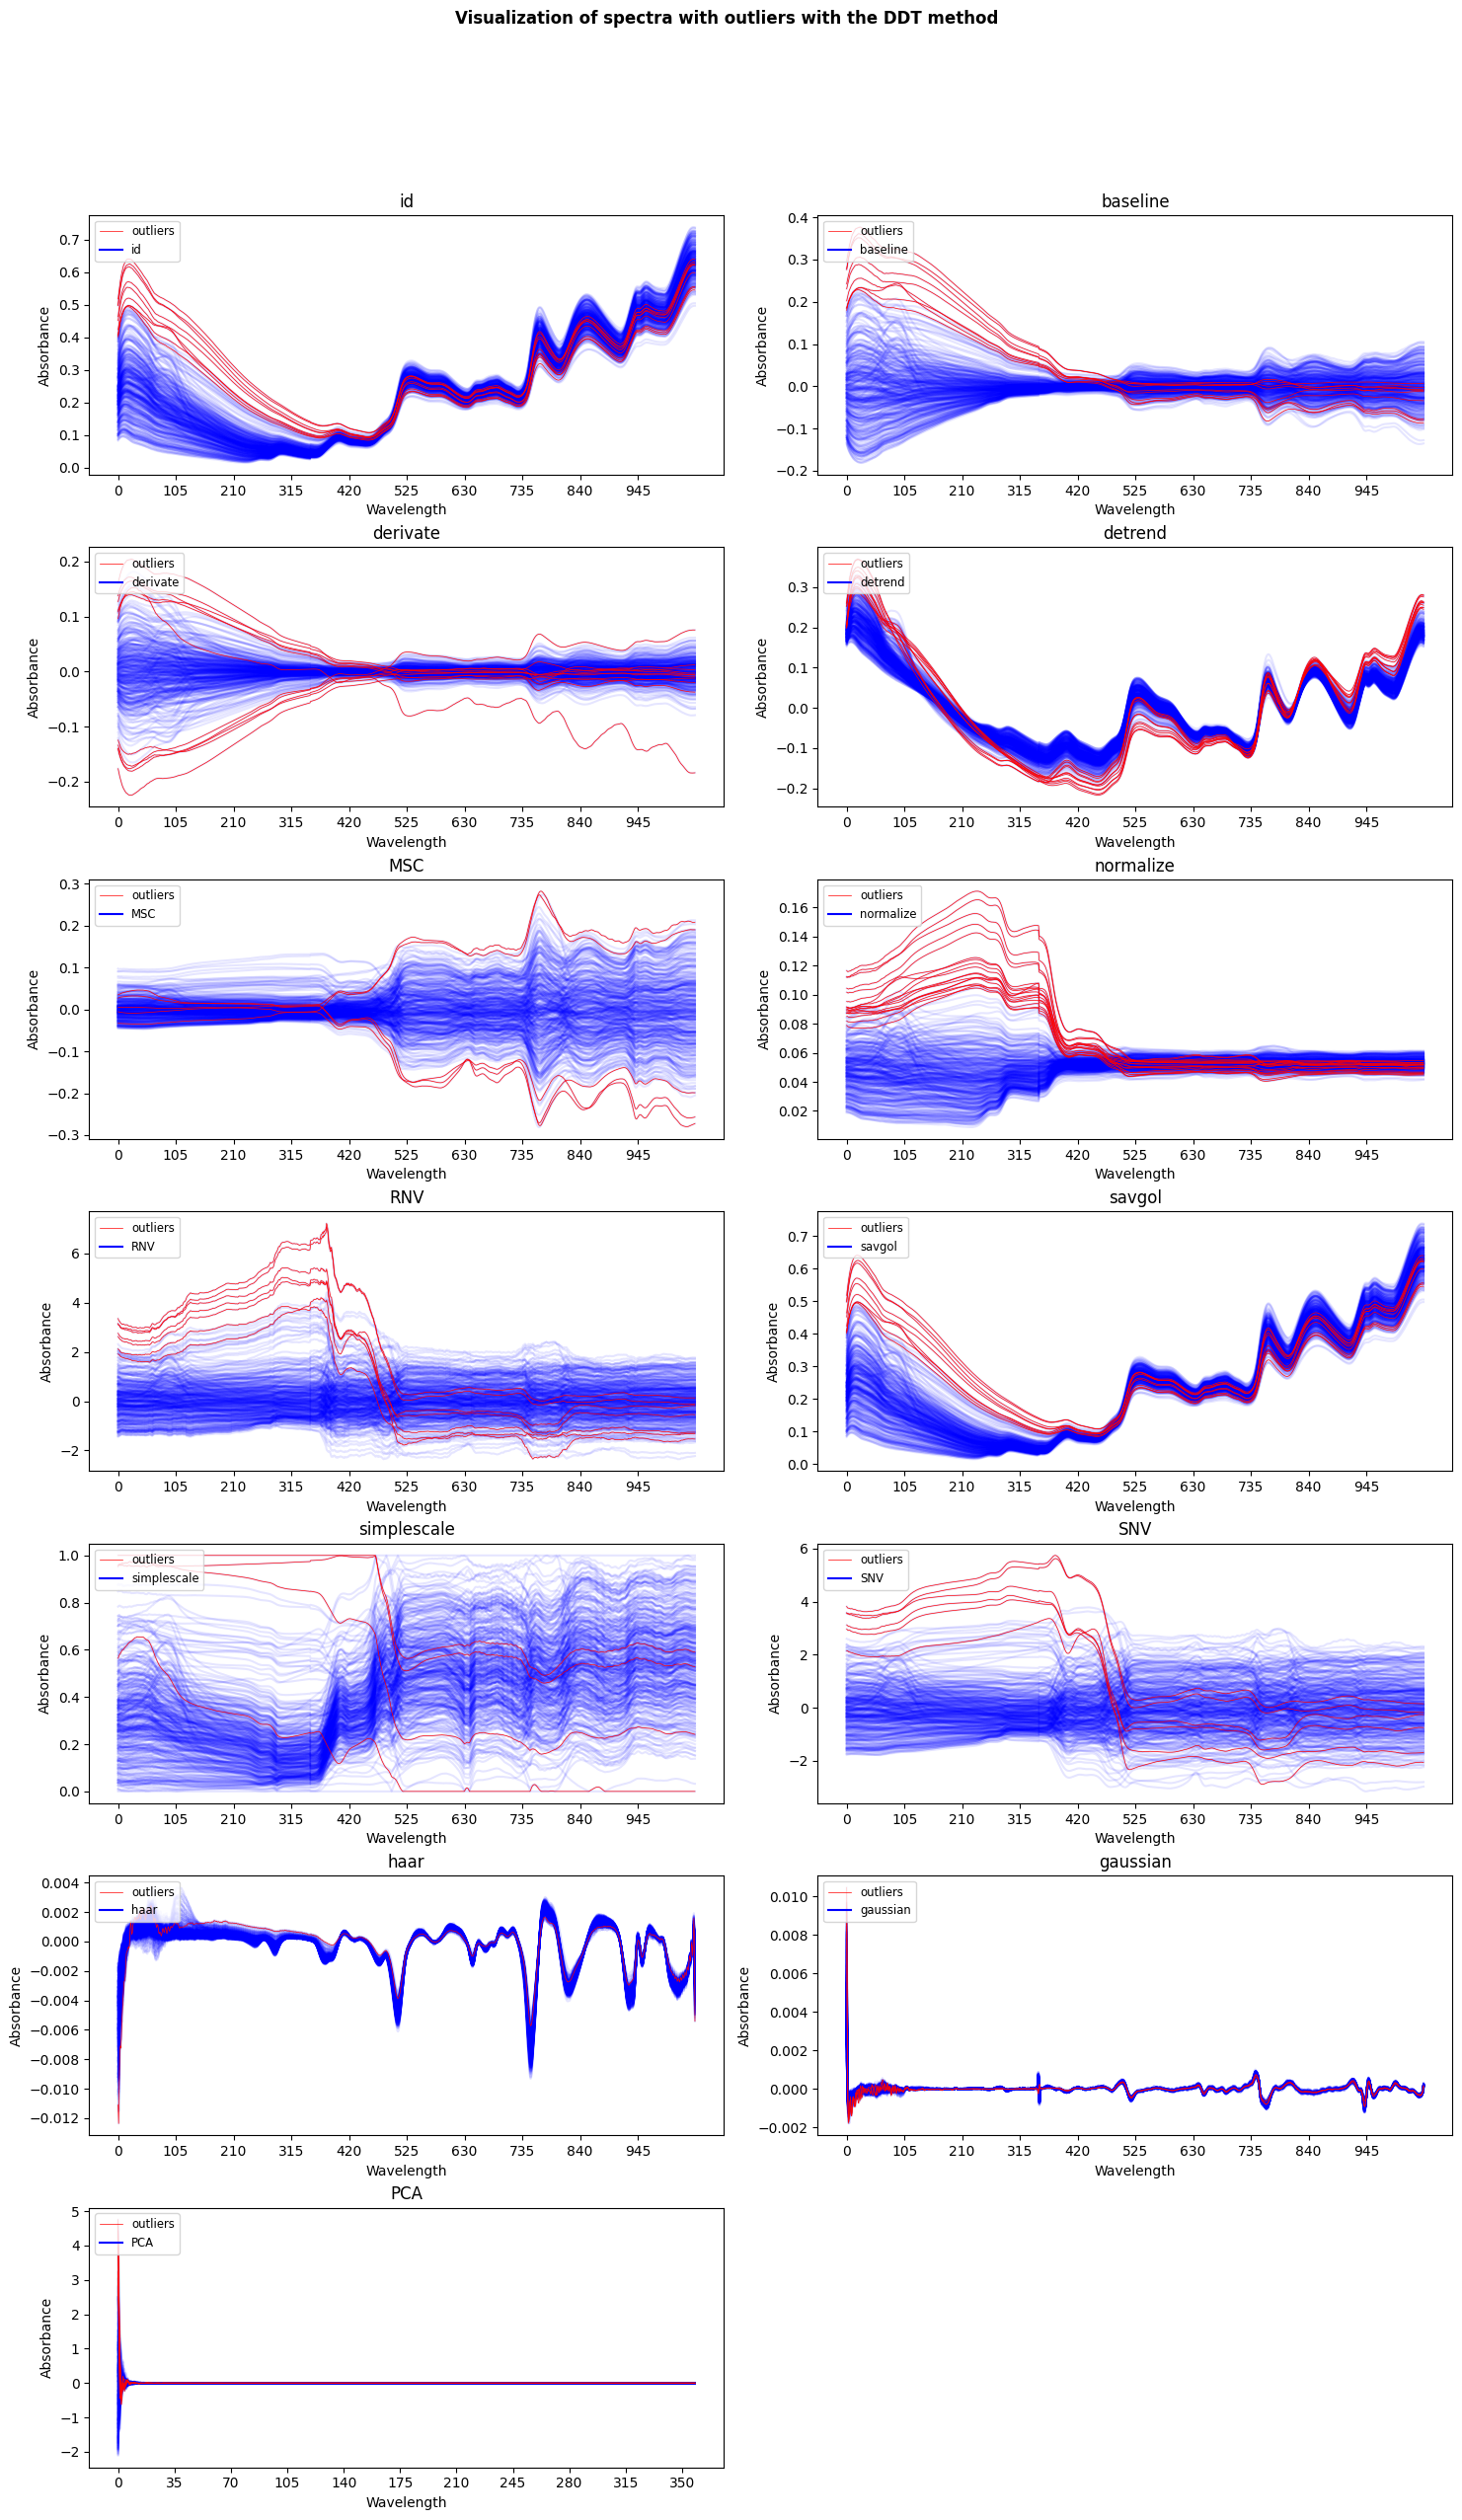

In [35]:
def plot_spectra_outliers(X, dict_outliers, names, title='Visualization of the spectra with outliers', save_fig=False):
    if isinstance(X, pd.DataFrame):
        X = [X.values]
    elif isinstance(X, np.ndarray):
            X = [X]

    fig, axs = plt.subplots((len(X)+1)//2, 2, figsize=(15, 4*len(X)//2), dpi=100)
    axs = axs.flatten()
    for i, ax in enumerate(axs):
        if i >= len(X):
            ax.axis('off')
        else:
            name = names[i]
            dataset = X[i]
            if isinstance(dataset, pd.DataFrame):
                 dataset = dataset.values
            outliers = dict_outliers[name]
            ax.set_title(name)
            ax.set_xlabel('Wavelength')
            ax.set_ylabel('Absorbance')
            ax.set_xticks(np.arange(0, dataset.shape[1], dataset.shape[1]//10))
            ax.plot(dataset.T, color='blue', alpha = 0.1)
            
            if len(outliers) > 0:
                ax.plot(dataset[outliers,:].T, color='red', linewidth=0.5)
                ax.plot([], [], color='red', label='outliers', linewidth=0.5)
            
            ax.plot([], [], color='blue', label=name)
            ax.legend(loc='upper left', fontsize='small')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.suptitle(title, fontweight='bold')
    
    # Save figure if required in the folder Figures/outliers_detection
    if save_fig: 
        fig.savefig("Figures/outliers_detection/DDT/%s_comp_dissimilarity.png" % data_source, dpi=300)
    plt.show()


# Plot the spectra
plot_spectra_outliers(list(transformed_datasets.values()),
                      dict_outliers = dict_outliers,
                      names = list(transformed_datasets.keys()),
                      title = 'Visualization of spectra with outliers with the DDT method',
                      save_fig = True)

#### Variant of this first method

In [36]:
def ddt_ddt_outlier_detection(X):
    N_T, n_x = X.shape
    outlier_mask = np.zeros(N_T, dtype=bool)

    for j in range(N_T):
        above_all = np.all(X[j, :] > X[np.arange(N_T) != j], axis=0).all()
        below_all = np.all(X[j, :] < X[np.arange(N_T) != j], axis=0).all()
        if above_all or below_all:
            outlier_mask[j] = True
    outliers_ind = list(np.where(outlier_mask)[0])
    return outliers_ind


In [37]:
dict_outliers = {}
for name, method in preprocessing:
    x = transformed_datasets[name]

    # Perform outliers detection with the DDT method
    outliers_ind = detect_outliers_DDT_ED(x, kM=2.0)

    # Add robustness to the process by performing another type of detection on non-outlier spectra
    x = np.delete(x, outliers_ind, axis=0)
    outliers_ind_else = ddt_ddt_outlier_detection(x)

    # Store the extreme individuals in the dictionary
    outliers_ind_all = list(np.concatenate((outliers_ind, outliers_ind_else), axis=0))
    dict_outliers[name] = [int(s) for s in outliers_ind_all]

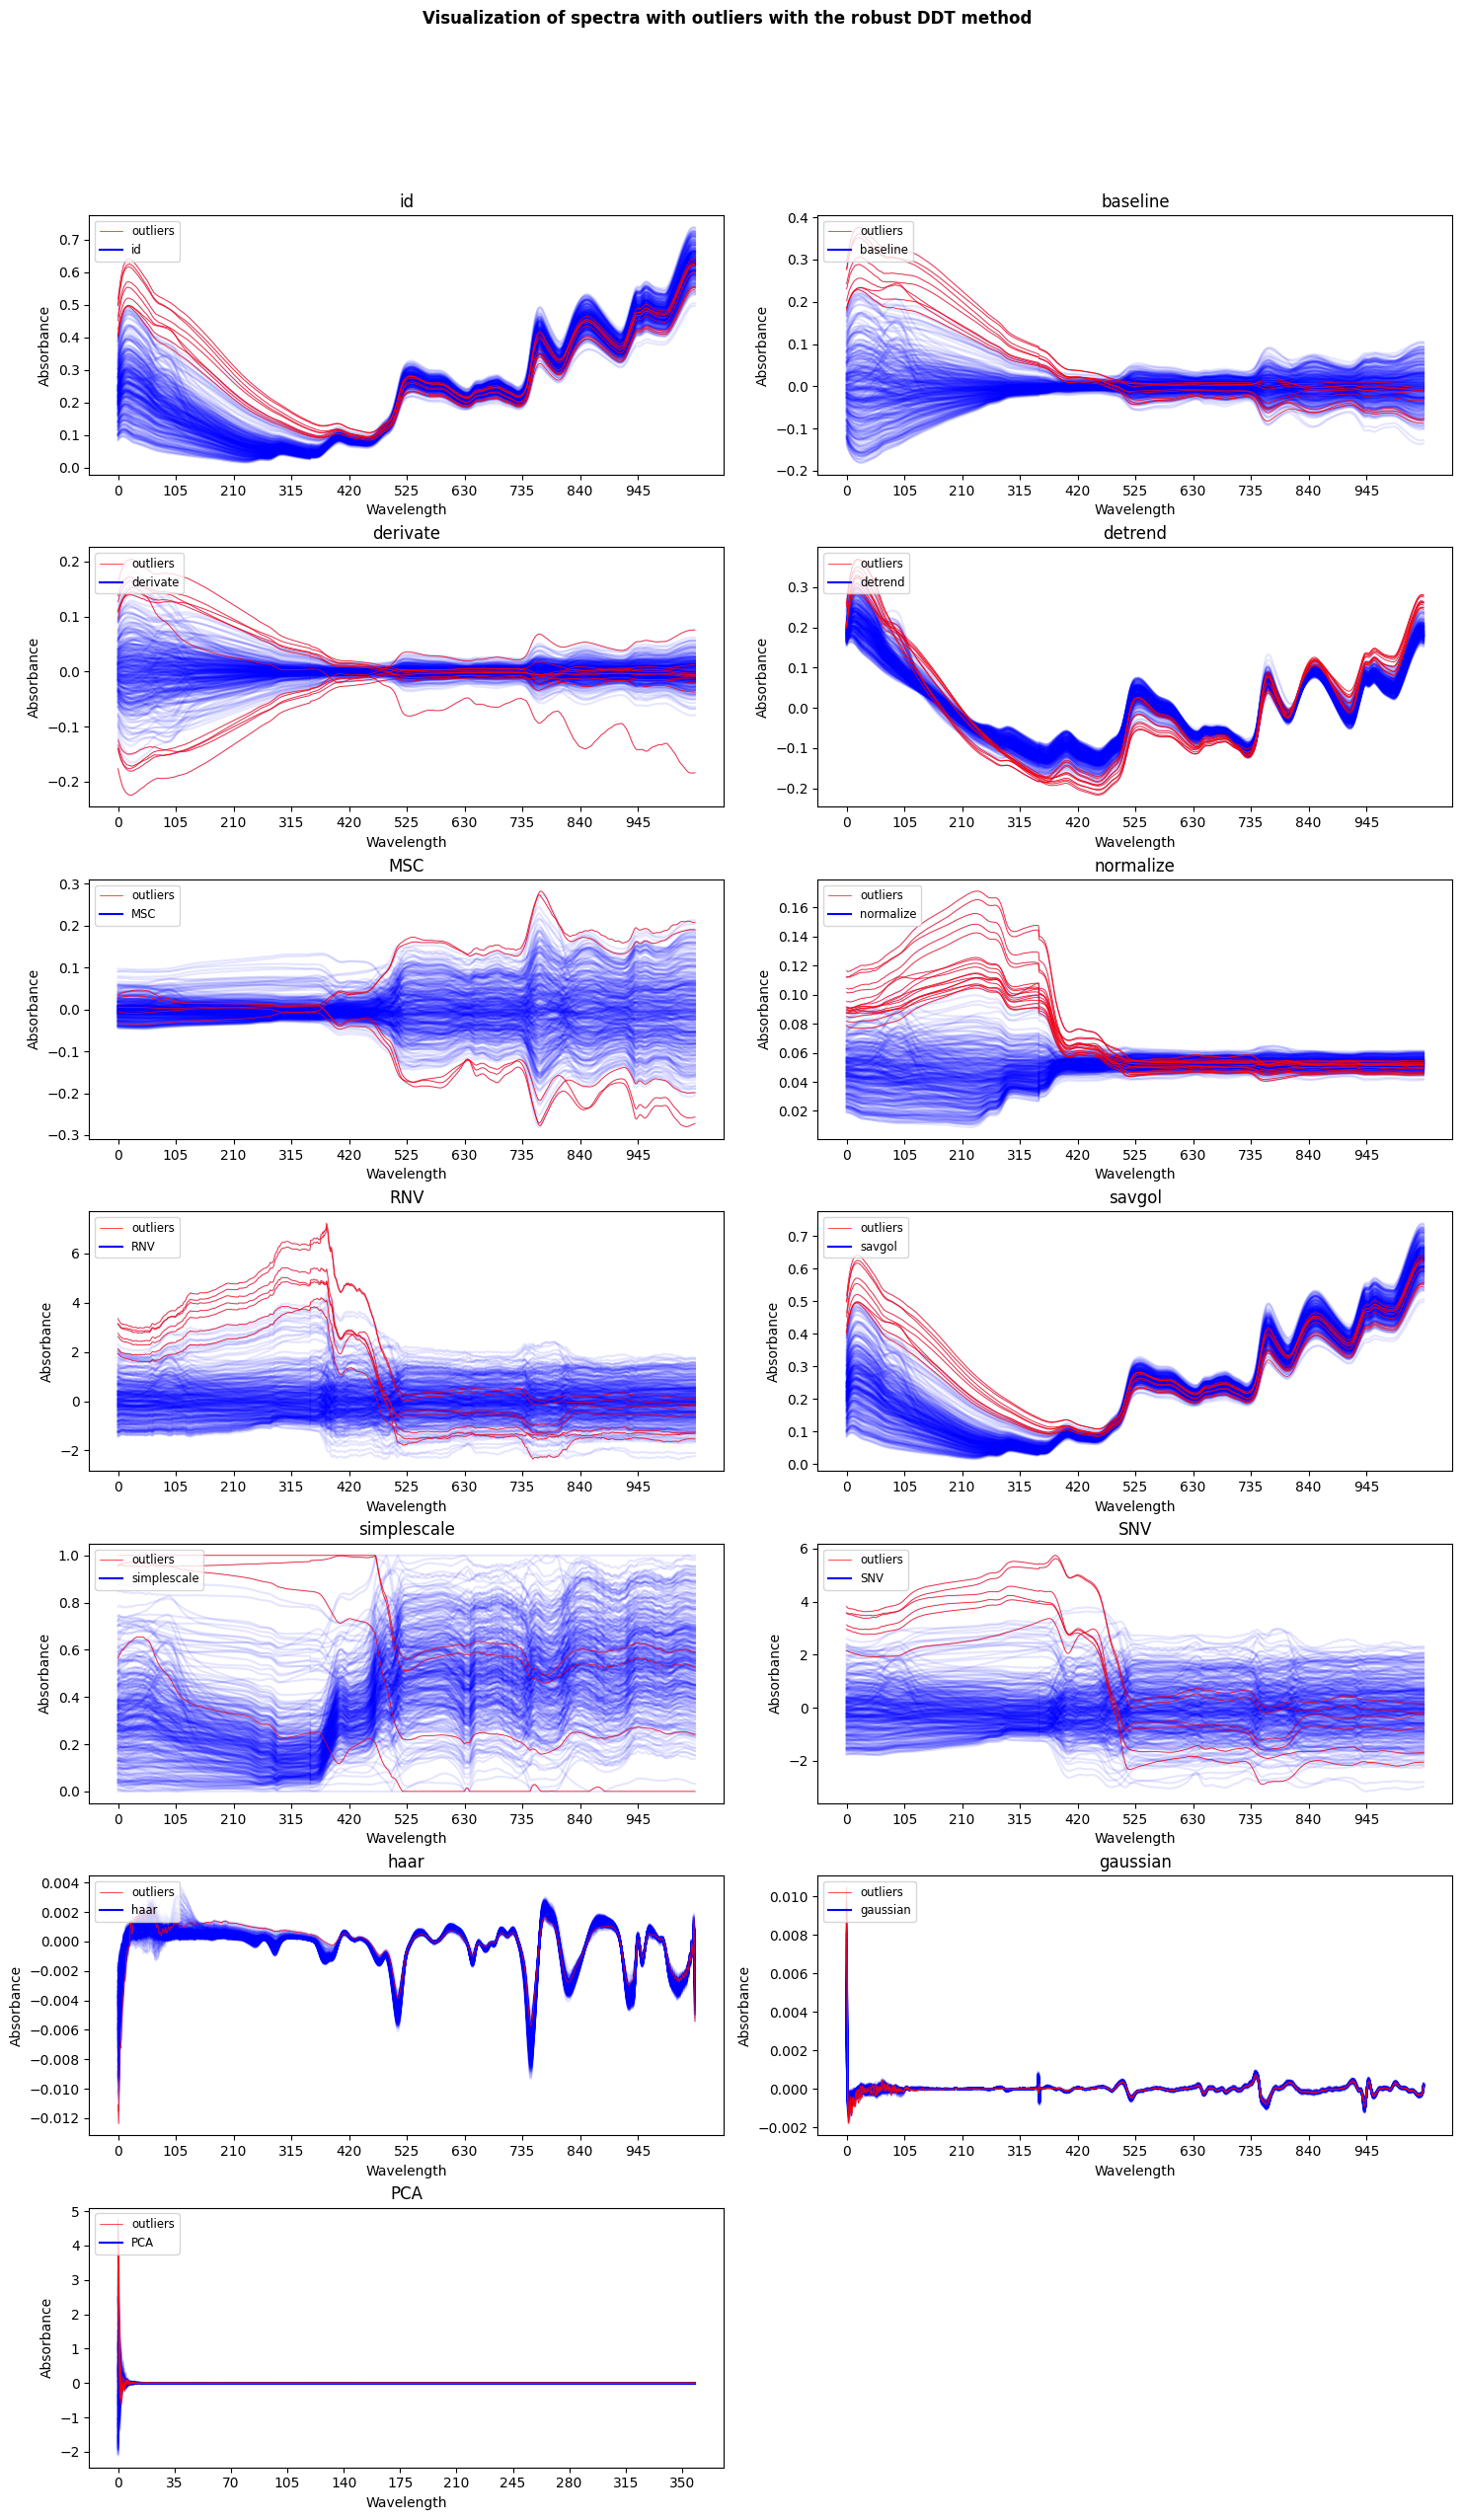

In [38]:
def plot_spectra_outliers(X, dict_outliers, names, title='Visualization of the spectra with outliers', save_fig=False):
    if isinstance(X, pd.DataFrame):
        X = [X.values]
    elif isinstance(X, np.ndarray):
            X = [X]

    fig, axs = plt.subplots((len(X)+1)//2, 2, figsize=(15, 4*len(X)//2), dpi=100)
    axs = axs.flatten()
    for i, ax in enumerate(axs):
        if i >= len(X):
            ax.axis('off')
        else:
            name = names[i]
            dataset = X[i]
            if isinstance(dataset, pd.DataFrame):
                 dataset = dataset.values
            outliers = dict_outliers[name]
            ax.set_title(name)
            ax.set_xlabel('Wavelength')
            ax.set_ylabel('Absorbance')
            ax.set_xticks(np.arange(0, dataset.shape[1], dataset.shape[1]//10))
            ax.plot(dataset.T, color='blue', alpha = 0.1)
            
            if len(outliers) > 0:
                ax.plot(dataset[outliers,:].T, color='red', linewidth=0.5)
                ax.plot([], [], color='red', label='outliers', linewidth=0.5)
            
            ax.plot([], [], color='blue', label=name)
            ax.legend(loc='upper left', fontsize='small')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.suptitle(title, fontweight='bold')
    
    # Save figure if required in the folder Figures/outliers_detection
    if save_fig: 
        fig.savefig("Figures/outliers_detection/DDT_robust/%s_comp_dissimilarity.png" % data_source, dpi=300)
    plt.show()


# Plot the spectra
plot_spectra_outliers(list(transformed_datasets.values()),
                      dict_outliers = dict_outliers,
                      names = list(transformed_datasets.keys()),
                      title = 'Visualization of spectra with outliers with the robust DDT method',
                      save_fig = True)

### Outliers detection with space transformation and spectral analysis

In [39]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
from sklearn.cluster import KMeans

def gaussian_kernel(x, y, sigma, D):
    div = (2 * np.pi * sigma)**(D/2)
    if div == 0: return 0 # justified with the comparison theorem on the exponential function when sigma tends to zero
    return np.exp(-np.linalg.norm(x - y)**2 / (2 * sigma**2))/div

def local_quadratic_entropy(X, neighbors, sigma):
    N, D = X.shape
    QE = np.zeros(N)
    for i in range(N):
        neigh_idx = list(neighbors[i])
        neighs = X[neigh_idx,:]
        total = 0
        for p in neighs:
            for q in neighs:
                total += gaussian_kernel(p, q, np.sqrt(2) * sigma, D)
        if len(neighs) == 0:
            QE[i] = 0
        else:
            QE[i] = -np.log(total / (len(neighs)**2))
    return QE

def compute_affinity_matrix(X, neighbors, QE, sigma, gamma):
    N = X.shape[0]
    K = np.zeros((N, N))
    for i in range(N):
        for j in neighbors[i]:
            if max(QE[i], QE[j]) == 0: 
                K[i, j] = 1
            else : 
                beta = min(QE[i], QE[j]) / max(QE[i], QE[j])
                if beta > gamma and max(QE[i], QE[j]) < np.mean(QE):
                    beta = np.mean(QE) / max(QE[i], QE[j])
                dist = np.linalg.norm(X[i] - X[j])
                coeff = (beta * sigma)**2
                if coeff == 0: # avoid errors with a division by zero
                    K[i, j] = 0
                else:
                    K[i, j] = np.exp(-dist**2 / (2 * coeff))
            K[j, i] = K[i, j]
    return K

def outdst(X, l_neighbors=10, gamma=0.7, c=0.05, d=3, with_distance=False, scale=False):
    N, D = X.shape

    if scale: 
        scaler = MinMaxScaler()
        X = scaler.fit_transform(X)

    sigma = np.mean(np.std(X, axis=0))  # robust estimate of sd

    # Find the l nearest neighbors of each individual
    nn = NearestNeighbors(n_neighbors=l_neighbors).fit(X)
    _, indices = nn.kneighbors(X)
    neighbors = [set(neigh) - {i} for i, neigh in enumerate(indices)]

    # Compute the local quadratic entropy
    QE = local_quadratic_entropy(X, neighbors, sigma)

    # Build the matrix giving weights to the edges of the graph
    K = compute_affinity_matrix(X, neighbors, QE, sigma, gamma)

    # Compute the Laplacian of the graph
    L = laplacian(K, normed=False)

    # Spectral decomposition
    vals, vecs = eigh(L)

    ### Keep the first dimensions of the span of eigenvectors
    if d == "Kaiser":
        vecs = vecs[:, 1:] # the first eigenvector is zero, we dump it
        mean_var = np.mean(np.var(vecs, axis=0)) # Compute the mean variance from all dimensions
        Y = vecs[:, np.var(vecs, axis=0) > mean_var] # Each dimension whose variance is over the mean variance is kept
    else:
        Y = vecs[:, 1:d+1]  # the first eigenvector is zero, we dump it
    
    scores = np.linalg.norm(Y, axis=1) 

    ### Detection of outliers based on the number of non zero components in eigenvectors
    non_zero_components = np.sum(Y!=0.0, axis=0) # number of non zero components per dimension
    dimensions_candidates = non_zero_components <= c * N # condition to verify if non zero components are sparse in the eigenvector

    # if non zero components are sparse in the eigenvector, they are considered outliers
    outliers = np.array([])
    for dimension, is_candidate in enumerate(dimensions_candidates):
        if is_candidate: 
            pos = np.where(Y[:, dimension] != 0.0)[0]
            outliers = np.concatenate((outliers, pos), axis=0)
    
    ### Detection of outliers based on their distance from the origin in the reduced space
    if with_distance:
        n_outliers = int(c * N)
    
        # Outliers are then the most remote vectors from the origin
        outliers_2 = np.argsort(scores)[-n_outliers:]

        # merge the outliers detected with both appraoches
        outliers = np.concatenate((outliers_2, outliers), axis=0)
    outliers = np.unique(outliers).astype(int)

    # If we spectra have been detected as outliers because they are equal to zero, remove it from the list
    outliers = [idx for idx in outliers if not np.all(X[idx] == 0)]

    
    return outliers


In [40]:
dict_outliers = {}
for name, method in preprocessing:
    x = transformed_datasets[name]
    if isinstance(x, pd.DataFrame): x = x.values

    # Perform outliers detection with the space transformation method
    outliers_ind = outdst(x, l_neighbors=15, gamma=0.7, c=0.01, d="Kaiser", scale=True)
    
    # Store the extreme individuals in the dictionary
    dict_outliers[name] = outliers_ind

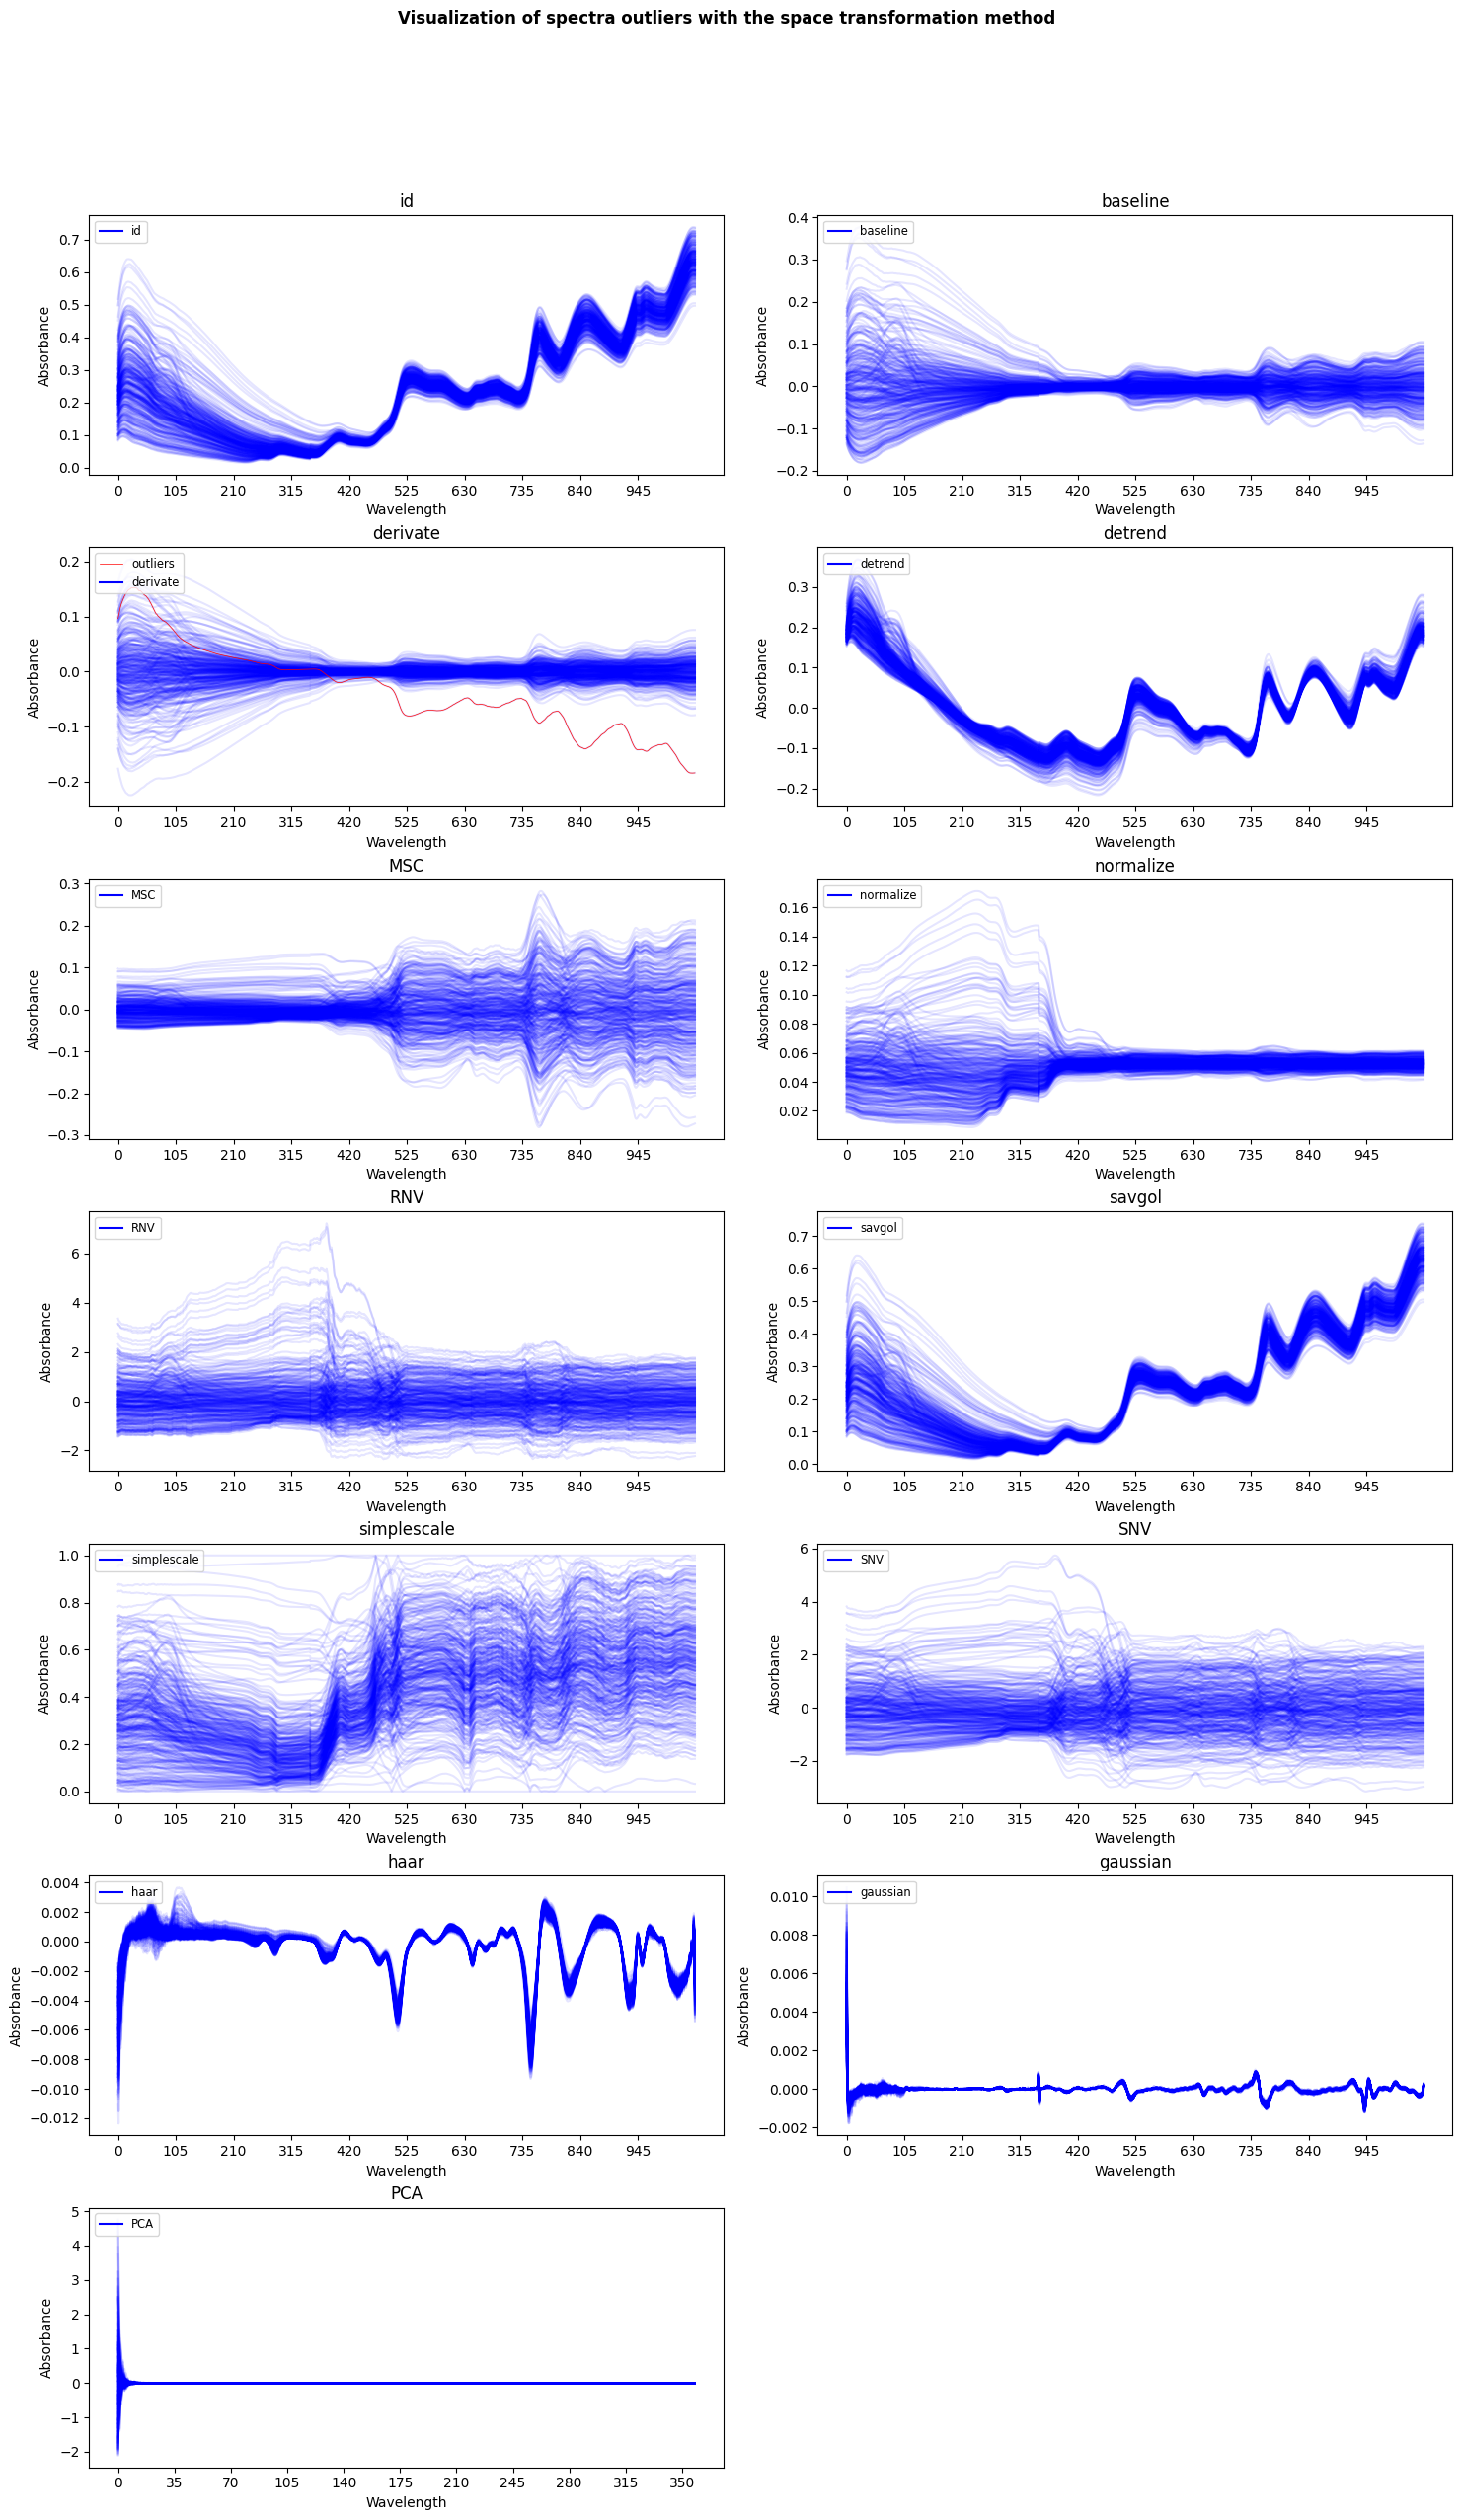

In [41]:
def plot_spectra_outliers(X, dict_outliers, names, title='Visualization of the spectra with outliers', save_fig=False):
    if isinstance(X, pd.DataFrame):
        X = [X.values]
    elif isinstance(X, np.ndarray):
            X = [X]

    fig, axs = plt.subplots((len(X)+1)//2, 2, figsize=(15, 4*len(X)//2), dpi=100)
    axs = axs.flatten()
    for i, ax in enumerate(axs):
        if i >= len(X):
            ax.axis('off')
        else:
            name = names[i]
            dataset = X[i]
            if isinstance(dataset, pd.DataFrame):
                 dataset = dataset.values
            outliers = dict_outliers[name]
            ax.set_title(name)
            ax.set_xlabel('Wavelength')
            ax.set_ylabel('Absorbance')
            ax.set_xticks(np.arange(0, dataset.shape[1], dataset.shape[1]//10))
            ax.plot(dataset.T, color='blue', alpha = 0.1)
            
            if len(outliers) > 0:
                ax.plot(dataset[outliers,:].T, color='red', linewidth=0.5)
                ax.plot([], [], color='red', label='outliers', linewidth=0.5)
            
            ax.plot([], [], color='blue', label=name)
            ax.legend(loc='upper left', fontsize='small')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.suptitle(title, fontweight='bold')
    
    # Save figure if required in the folder Figures/outliers_detection
    if save_fig: 
        fig.savefig("Figures/outliers_detection/Space_transformation/%s_comp_dissimilarity.png" % data_source, dpi=300)
    plt.show()


# Plot the spectra
plot_spectra_outliers(list(transformed_datasets.values()),
                      dict_outliers = dict_outliers,
                      names = list(transformed_datasets.keys()),
                      title = 'Visualization of spectra outliers with the space transformation method',
                      save_fig = True)

### 1 — Objectif & Contexte

**Objectif** : Identifier des **outliers** (globaux ou locaux) sans hypothèse sur la distribution.

**Problème des méthodes classiques :**
- Sensibles aux formes non-convexes
- Inefficaces avec densités variables

**Idée générale :**
1. Transformation de l’espace des données (via un graphe)
2. Pondération adaptative par entropie locale
3. Analyse spectrale pour détecter les outliers


---

### 2 — Graphe & Entropie Locale

**Graphe G = (V, E)** :
- Sommets = spectres
- Arêtes = voisins proches (ℓ-nearest neighbors)

**Matrice de poids** :

$K_{ij} = \exp\left(-\frac{\|x_i - x_j\|^2}{2(\beta \sigma)^2}\right)$

**Entropie quadratique locale :**

$ 
QE(x) = -\log\left( \frac{1}{(\ell+1)^2} \sum_{p,q} G(x_p - x_q, 2\sigma^2) \right), \quad
\beta(x_i, x_j) = \frac{\\min(QE(x_i), QE(x_j))}{\max(QE(x_i), QE(x_j))}
$

---

### 3 — Analyse Spectrale

**Fonction à minimiser :**

$Y^* = \underset{Y}{\text{argmin}}\sum_i \sum_j \|y_i - y_j \|^2 K_{ij}$

**Laplacien du graphe :**

$
L = D - K \quad \text{où } D_{ii} = \sum_j K_{ij}
$

**Optimisation spectrale :**

$
\min_f f^T L f \quad \text{avec } f^T f = 1, \quad f = Y^{T}
$

**Problème de détermination de valeurs propres :**

$
Lf = \lambda f
$

- Valeurs nulles → outliers globaux
- Sauts de valeurs propres → outliers locaux

---

### 4 — Détection des Outliers

##### Globaux :
- Faible connectivité → λ ≈ 0
- Valeurs extrêmes dans un seul vecteur propre

##### Locaux :
- Subtils, dans une composante faiblement connectée
- Détectés via discontinuités dans f₂

---

### 5 — Résultats & Avantages

**Avantages :**
- Pas d'hypothèses sur les distributions
- Robuste aux formes complexes, densités variables

**Complexité :**

$
\mathcal{O}(DN \log N)
$

